#Gear ratio Calculator

This script calculates the ideal gear ratio for a dual pull boom deployment mechanism
The equations that are implmented are from Advanced Dual-Pull Mechanism for Deployable Spacecraft Booms, by Firth and Pankow
The paper is obtainable here https://www.researchgate.net/publication/329423056_Advanced_Dual-Pull_Mechanism_for_Deployable_Spacecraft_Booms

To run this script you need the thickness of the boom, the thickness of the tape, the length of the boom,
hub core radius, pinion radius 

In [1]:
import math
from scipy.optimize import brentq
import numpy as np
import matplotlib.pyplot as plt

#Helper functions

In [2]:
# This function returns the arc length of the boom as a function of theta p
def boom_length(theta_p, tape_thickness, theta_p0, s_p0, target_s):
    s = (tape_thickness / (4*math.pi)) * ((theta_p + theta_p0) * math.sqrt(1 + (theta_p + theta_p0)**2) + math.asinh(theta_p + theta_p0)) - s_p0
    # Bring function to 0 at target_s
    s = s - target_s
    return s 

# This functions returns the arc length of the boom as a function of theta h 
def hub_length(theta_h,tape_thickness, boom_thickness, theta_h0, s_h0, s_max, target_s):
    s = s_max - ((tape_thickness+boom_thickness) / (4*math.pi)) * ((theta_h + theta_h0) * math.sqrt(1 + (theta_h + theta_h0)**2) + math.asinh(theta_h + theta_h0)) + s_h0
    # No need to bring this function to 0 at the target since it already is 
    return s - (s_max - target_s)  # find theta_h where remaining == s_max - target_s

def arc_length(theta, a, s):
    return s - (a / (4*math.pi)) * ((theta) * math.sqrt(1 + (theta)**2) + math.asinh(theta))

def calculate_gear_ratio(boom_thickness, tape_thickness, s_max, s_p0, theta_p0, s_h0, theta_h0, target_s):

    # Solve equation 3 for the max theta p, the max amount of radians the pinion turns
    # set some bounds for theta p, 
    theta_p_min = 0
    theta_p_cap = 5000
    max_theta_p = brentq(boom_length, theta_p_min, theta_p_cap, args=(tape_thickness, theta_p0, s_p0, target_s))

    # Solve equation 4 for the max theta h, the max amount of radians the hub turns
    # set some bounds for theta h,
    theta_h_min = 0 
    theta_h_cap = 5000
    max_theta_h = brentq(hub_length, theta_h_min, theta_h_cap, args=(tape_thickness, boom_thickness, theta_h0, s_h0, s_max, target_s))

    # Calculate the gear ratio, the ratio of the angle the pinion turns to the angle the hub turns
    gear_ratio = max_theta_p / max_theta_h

    return gear_ratio, max_theta_p, max_theta_h

Initial Values

In [3]:
# Note on units: Since archimedes spiral is purely geometric, we just need to keep the same units for all the parameters, so we can use mm for all lengths and radians for angles, the gear ratio is unitless so it does not matter.
boom_thickness = 0.1 # in mm
tape_thickness = 0.06 # in mm
max_boom_length = 10000 # in mm (10m)
a = boom_thickness + tape_thickness # in mm, the distance between the center of the pinion and the center of the hub, this is the "a" parameter in the equations

hub_radius = 10 # in mm
pinion_radius = 4.5 # in mm

# Values for hub radius as if they were made from tape and boom material 
theta_hub_radius = hub_radius * 2 * math.pi / a 
equivalent_hub_length = (a / (4*math.pi)) * ((theta_hub_radius) * math.sqrt(1 + (theta_hub_radius)**2) + math.asinh(theta_hub_radius))
total_hub_length = equivalent_hub_length + max_boom_length

# Values for pinion radius as if they were made from tape material. assume initial kapton turns around spool are negligible 
theta_pinion_radius = pinion_radius * 2 * math.pi / tape_thickness
equivalent_pinion_length = (tape_thickness / (4*math.pi)) * ((theta_pinion_radius) * math.sqrt(1 + (theta_pinion_radius)**2) + math.asinh(theta_pinion_radius))


# Setup angle intervals for brentq 
theta_min = 0
theta_max = 5000
# Set the variables to the ones we use in the equations 
initially_coiled_pinion_length = equivalent_pinion_length 
initially_coiled_pinion_angle = brentq(arc_length, theta_min, theta_max, args=(tape_thickness, initially_coiled_pinion_length))
initially_coiled_hub_length = total_hub_length 
initially_coiled_hub_angle = brentq(arc_length, theta_min, theta_max, args=(a, initially_coiled_hub_length))

print(f"Initially coiled pinion length: {initially_coiled_pinion_length} mm")
print(f"Initially coiled pinion angle: {initially_coiled_pinion_angle} radians")
print(f"Initially coiled hub length: {initially_coiled_hub_length} mm")
print(f"Initially coiled hub angle: {initially_coiled_hub_angle} radians")




Initially coiled pinion length: 1060.322607151239 mm
Initially coiled pinion angle: 471.23889803846896 radians
Initially coiled hub length: 11963.586651279105 mm
Initially coiled hub angle: 969.3347350625448 radians


In [4]:
# Rename variables to equation parameters
s_max = max_boom_length
s_p0 = initially_coiled_pinion_length
theta_p0 = initially_coiled_pinion_angle
s_h0 = initially_coiled_hub_length
theta_h0 = initially_coiled_hub_angle

Gear Ratio Calculation

In [5]:
target_s = max_boom_length
calculated_gear_ratio, max_theta_p, max_theta_h = calculate_gear_ratio(boom_thickness, tape_thickness, s_max, s_p0, theta_p0, s_h0, theta_h0, target_s)

print(f"Calculated gear ratio: {calculated_gear_ratio}")
print(f"Max theta p: {max_theta_p} radians")    
print(f"Max theta h: {max_theta_h} radians")

Calculated gear ratio: 3.053975906866594
Max theta p: 1050.7532271080545 radians
Max theta h: 344.0607454517008 radians


Find the revolutions the spring needs to be able to handle

Max spring excursion: 33.04935977186369 radians
Max spring excursion: 5.259968973714541 revolutions
Boom length at max slip: 3303.3033033033034 mm


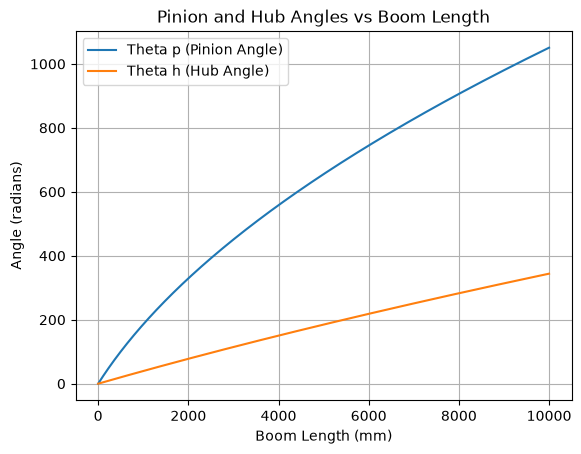

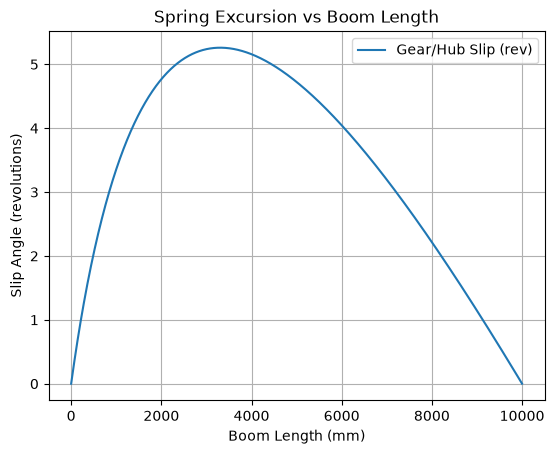

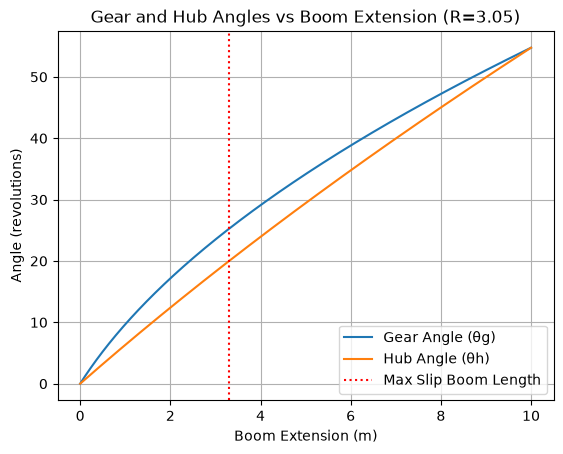

In [ ]:
# To find the revolutions the spring needs to withstand, we need to calculate the difference between both gear ratios. 

# Set up samples 
arc_length = np.linspace(0, max_boom_length, 1000)
theta_h_values = []
theta_p_values = []
gear_angle_values = []
slip_angle_values = []

for target_s in arc_length:
    # Calculate the theta h and theta p values for each point on the boom length
    # Solve equation 3 for theta p
    theta_p_min = 0
    theta_p_cap = 5000
    theta_p = brentq(boom_length, theta_p_min, theta_p_cap, args=(tape_thickness, theta_p0, s_p0, target_s))
    theta_p_values.append(theta_p)

    # Solve equation 4 for the max theta h, the max amount of radians the hub turns
    # set some bounds for theta h,
    theta_h_min = 0 
    theta_h_cap = 5000
    theta_h = brentq(hub_length, theta_h_min, theta_h_cap, args=(tape_thickness, boom_thickness, theta_h0, s_h0, s_max, target_s))
    theta_h_values.append(theta_h)

    # Solve for gear angle values 
    gear_angle = theta_p / calculated_gear_ratio
    gear_angle_values.append(gear_angle)
    
    
    # Solve for the difference in hub vs gear angle. Since Theta gear - Theta hub = theta pinion / gear ratio - theta hub
    slip_angle = theta_p / calculated_gear_ratio - theta_h
    slip_angle_values.append(slip_angle)


# Find max revolutions of spring 
max_slip_radians = max(slip_angle_values)
max_slip_index = slip_angle_values.index(max_slip_radians)
max_slip_boom_length = arc_length[max_slip_index]
max_slip_revolutions = max_slip_radians / (2 * math.pi)

print(f"Max spring excursion: {max_slip_radians} radians")
print(f"Max spring excursion: {max_slip_revolutions} revolutions")
print(f"Boom length at max slip: {max_slip_boom_length} mm")

# Graph the results to see the divergence of the angles as the boom length increases. 

plt.plot(arc_length, theta_p_values, label='Theta p (Pinion Angle)')
plt.plot(arc_length, theta_h_values, label='Theta h (Hub Angle)')
plt.xlabel('Boom Length (mm)')
plt.ylabel('Angle (radians)')
plt.title('Pinion and Hub Angles vs Boom Length')
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(arc_length, [s / (2 * math.pi) for s in slip_angle_values], label='Gear/Hub Slip (rev)')
plt.xlabel('Boom Length (mm)')
plt.ylabel('Slip Angle (revolutions)')
plt.title('Spring Excursion vs Boom Length')
plt.legend()
plt.grid()
plt.show()


# Check gear and hub angle converge 
plt.figure()
# plt.plot(arc_length / 1000, theta_p_values, label='Gear Angle (θp/R)')
plt.plot(arc_length / 1000, [s / (2 * math.pi) for s in gear_angle_values], label='Gear Angle (θg)')
plt.plot(arc_length / 1000, [s / (2 * math.pi) for s in theta_h_values], label='Hub Angle (θh)')

plt.xlabel('Boom Extension (m)')
plt.ylabel('Angle (revolutions)')
plt.title(f'Gear and Hub Angles vs Boom Extension (R={calculated_gear_ratio:.2f})')
plt.axvline(x=max_slip_boom_length / 1000, linestyle=':', color='red', label=f'Max Slip of {max_slip_revolutions:.2f} revs at {max_slip_boom_length/1000:.2f} m')
plt.legend()
plt.grid()
plt.show()